### Install All Required Libraries

In [3]:
!pip install fastapi uvicorn nest-asyncio pyngrok wikipedia-api

In [4]:
# Verify all imports
import tensorflow as tf
import numpy as np
import pandas as pd
import wikipediaapi

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("✅ All libraries loaded successfully!")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
✅ All libraries loaded successfully!


####STEP 2: Collecting the Dataset

Fetch real text data from Wikipedia using the API

Look at the raw data

Understand what we're working with

Fetch Text Data from Wikipedia

In [5]:
import wikipediaapi

# Initialize Wikipedia API with a user agent (required)
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='LSTMTextPrediction/1.0'
)

# Fetch multiple topics to get enough training data
topics = [
    "Artificial intelligence",
    "Machine learning",
    "Deep learning",
    "Neural network",
    "Natural language processing"
]

# Collect all text into one big string
raw_text = ""

for topic in topics:
    page = wiki.page(topic)
    if page.exists():
        raw_text += page.text + " "
        print(f"✅ Fetched: {topic} — {len(page.text)} characters")
    else:
        print(f"❌ Page not found: {topic}")

print(f"\n📊 Total text collected: {len(raw_text)} characters")
print(f"\n--- First 500 characters preview ---\n")
print(raw_text[:500])

✅ Fetched: Artificial intelligence — 83584 characters
✅ Fetched: Machine learning — 58868 characters
✅ Fetched: Deep learning — 56208 characters
✅ Fetched: Neural network — 5304 characters
✅ Fetched: Natural language processing — 32223 characters

📊 Total text collected: 236192 characters

--- First 500 characters preview ---

Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.
High-pr


STEP 3: Data Preprocessing

Clean the raw text                                                               
Convert words into numbers (LSTM can't read words, only numbers)                 
Create input-output pairs for training

3.1 — Clean the Text

In [6]:
import re

def clean_text(text):
    text = text.lower()                        # convert to lowercase
    text = re.sub(r'\n', ' ', text)            # remove newlines
    text = re.sub(r'[^a-z0-9\s]', '', text)   # remove special characters
    text = re.sub(r'\s+', ' ', text)           # remove extra spaces
    text = text.strip()
    return text

cleaned_text = clean_text(raw_text)

print("✅ Text cleaned!")
print(f"Total characters after cleaning: {len(cleaned_text)}")
print(f"\n--- First 300 characters preview ---")
print(cleaned_text[:300])

✅ Text cleaned!
Total characters after cleaning: 227295

--- First 300 characters preview ---
artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problemsolving perception and decisionmaking it is a field of research in engineering mathematics and computer science that develops and stud


3.2 — Tokenize (Convert Words → Numbers)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Split text into words
words = cleaned_text.split()
print(f"Total words: {len(words)}")

# Keep only top 5000 most common words (keeps model manageable)
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts([cleaned_text])

vocab_size = min(5000, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")
print(f"\nSample word → number mappings:")
sample_words = list(tokenizer.word_index.items())[:10]
for word, index in sample_words:
    print(f"  '{word}' → {index}")

Total words: 34572
Vocabulary size: 5000

Sample word → number mappings:
  '<OOV>' → 1
  'the' → 2
  'of' → 3
  'and' → 4
  'to' → 5
  'a' → 6
  'in' → 7
  'that' → 8
  'learning' → 9
  'is' → 10


3.3 — Create Input-Output Sequences

In [8]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Convert all text to a sequence of numbers
token_list = tokenizer.texts_to_sequences([cleaned_text])[0]
print(f"Total tokens in dataset: {len(token_list)}")

# Create sequences of length 10
# Example: [1,2,3,4,5,6,7,8,9] → predicts 10
SEQ_LENGTH = 10
sequences = []

for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i-SEQ_LENGTH:i+1]  # 10 inputs + 1 output
    sequences.append(seq)

print(f"Total sequences created: {len(sequences)}")

# Split into X (input) and y (output)
sequences = np.array(sequences)
X = sequences[:, :-1]   # all columns except last
y = sequences[:, -1]    # last column only

# One-hot encode the output
y = to_categorical(y, num_classes=vocab_size)

print(f"\nX shape: {X.shape}  ← (samples, sequence_length)")
print(f"y shape: {y.shape}  ← (samples, vocab_size)")
print(f"\n✅ Preprocessing complete!")

Total tokens in dataset: 34572
Total sequences created: 34562

X shape: (34562, 10)  ← (samples, sequence_length)
y shape: (34562, 5000)  ← (samples, vocab_size)

✅ Preprocessing complete!


STEP 4: Building & Training the LSTM Model

Build the LSTM architecture                                                      
Understand what each layer does                                                  
Train the model

4.1 — Build the LSTM Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    # Layer 1: Embedding - converts word numbers into dense vectors
    Embedding(input_dim=vocab_size, output_dim=100, input_length=SEQ_LENGTH),

    # Layer 2: First LSTM - learns patterns in sequences
    LSTM(150, return_sequences=True),

    # Layer 3: Dropout - prevents overfitting (randomly drops 20% neurons)
    Dropout(0.2),

    # Layer 4: Second LSTM - learns higher level patterns
    LSTM(100),

    # Layer 5: Dropout again
    Dropout(0.2),

    # Layer 6: Dense output - predicts probability for each word
    Dense(vocab_size, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

4.2 — Train the Model

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training early if no improvement for 3 epochs
early_stop = EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("🚀 Starting training... (this will take 3-5 minutes on Colab GPU)")

history = model.fit(
    X, y,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")
print(f"Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")

🚀 Starting training... (this will take 3-5 minutes on Colab GPU)
Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.0427 - loss: 7.2105
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0464 - loss: 6.7948
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0462 - loss: 6.7593
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0516 - loss: 6.6652
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0592 - loss: 6.5622
Epoch 6/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0635 - loss: 6.4955
Epoch 7/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0670 - loss: 6.4398
Epoch 8/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0708 - loss: 6.3880
Epoch 9/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0752 - loss: 6.3336
Epoch 10/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0815 - loss: 6.2872
Epoch 11/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accurac

STEP 5: Save the Model & Test Predictions

5.1 — Save the Model

In [10]:
import pickle

# Save the trained model
model.save('lstm_text_model.h5')

# Save the tokenizer (we need this for predictions later)
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("✅ Model saved as: lstm_text_model.h5")
print("✅ Tokenizer saved as: tokenizer.pkl")

✅ Model saved as: lstm_text_model.h5
✅ Tokenizer saved as: tokenizer.pkl


5.2 — Test Predictions

In [11]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_words(seed_text, num_words=5):
    """
    Given a seed sentence, predict the next N words
    seed_text : starting sentence
    num_words : how many words to predict
    """
    result = seed_text

    for _ in range(num_words):
        # Convert seed text to numbers
        token_list = tokenizer.texts_to_sequences([result])[0]

        # Pad to match SEQ_LENGTH
        token_list = pad_sequences(
            [token_list],
            maxlen=SEQ_LENGTH,
            padding='pre'
        )

        # Predict probabilities for each word
        predicted_probs = model.predict(token_list, verbose=0)

        # Pick the word with highest probability
        predicted_index = np.argmax(predicted_probs)

        # Convert number back to word
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break

        result += " " + predicted_word

    return result

# ---- Test it ----
print("🔮 Testing predictions:\n")

test_sentences = [
    "artificial intelligence is",
    "deep learning models are",
    "neural networks can learn",
]

for sentence in test_sentences:
    prediction = predict_next_words(sentence, num_words=5)
    print(f"Input : '{sentence}'")
    print(f"Output: '{prediction}'")
    print()

🔮 Testing predictions:

Input : 'artificial intelligence is'
Output: 'artificial intelligence is a <OOV> of the <OOV>'

Input : 'deep learning models are'
Output: 'deep learning models are <OOV> and <OOV> <OOV> <OOV>'

Input : 'neural networks can learn'
Output: 'neural networks can learn in the <OOV> <OOV> is'



STEP 6: Building the FastAPI /predict Endpoint

Write the FastAPI app                                                              
Run it inside Colab using pyngrok (gives a public URL)                           
Test it via Swagger UI

6.1 — Write the FastAPI App

In [12]:
# Write the FastAPI app to a file
api_code = '''
import pickle
import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize app
app = FastAPI(
    title="LSTM Text Prediction API",
    description="Predicts the next words in a sequence using an LSTM model",
    version="1.0.0"
)

# Load model and tokenizer
model = load_model("lstm_text_model.h5")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

SEQ_LENGTH = 10
VOCAB_SIZE = 5000

# Request body structure
class PredictRequest(BaseModel):
    seed_text: str
    num_words: int = 5

# Response body structure
class PredictResponse(BaseModel):
    input_text: str
    predicted_text: str
    next_words: list

# Root endpoint
@app.get("/")
def home():
    return {
        "message": "LSTM Text Prediction API is running!",
        "endpoints": {
            "predict": "/predict",
            "docs": "/docs",
            "health": "/health"
        }
    }

# Health check endpoint
@app.get("/health")
def health():
    return {"status": "healthy", "model": "LSTM", "vocab_size": VOCAB_SIZE}

# Main prediction endpoint
@app.post("/predict")
def predict(request: PredictRequest):
    result = request.seed_text
    next_words = []

    for _ in range(request.num_words):
        # Tokenize input
        token_list = tokenizer.texts_to_sequences([result])[0]

        # Pad sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=SEQ_LENGTH,
            padding="pre"
        )

        # Predict
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))

        # Index to word
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break

        next_words.append(predicted_word)
        result += " " + predicted_word

    return PredictResponse(
        input_text=request.seed_text,
        predicted_text=result,
        next_words=next_words
    )
'''

# Save to file
with open("prediction_api.py", "w") as f:
    f.write(api_code)

print("✅ prediction_api.py created successfully!")

✅ prediction_api.py created successfully!


6.2 — Run the FastAPI Server with Public URL

In [13]:
from pyngrok import ngrok

# Paste your token here between the quotes
ngrok.set_auth_token("3CiH0ALxVWzRK3qH17KkKjQvHsv_2MZY5QGf8Jj58A88wf2bu")

print("✅ ngrok authenticated successfully!")

✅ ngrok authenticated successfully!


In [14]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading

nest_asyncio.apply()

# Start ngrok tunnel on port 8000
public_url = ngrok.connect(8000)
print(f"✅ Public URL: {public_url}")
print(f"📖 Swagger Docs: {public_url}/docs")
print(f"🔮 Predict endpoint: {public_url}/predict")
print(f"\n⚠️  Keep this cell running — server is live!")

# Run FastAPI in background thread
def run_server():
    import prediction_api
    uvicorn.run(prediction_api.app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

# Keep alive
import time
while True:
    time.sleep(1)

✅ Public URL: NgrokTunnel: "https://chosen-commuting-privacy.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger Docs: NgrokTunnel: "https://chosen-commuting-privacy.ngrok-free.dev" -> "http://localhost:8000"/docs
🔮 Predict endpoint: NgrokTunnel: "https://chosen-commuting-privacy.ngrok-free.dev" -> "http://localhost:8000"/predict

⚠️  Keep this cell running — server is live!


INFO:     Started server process [8865]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


KeyboardInterrupt: 

In [15]:
# =============================================
# IMPROVED TRAINING — Better predictions
# =============================================

import re
import numpy as np
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import wikipediaapi

# ---- Step 1: Fetch more data ----
wiki = wikipediaapi.Wikipedia(language='en', user_agent='LSTMTextPrediction/1.0')

topics = [
    "Artificial intelligence",
    "Machine learning",
    "Deep learning",
    "Neural network",
    "Natural language processing",
    "Computer science",        # ← new
    "Data science",            # ← new
    "Robotics",                # ← new
    "Computer vision",         # ← new
    "Reinforcement learning"   # ← new
]

raw_text = ""
for topic in topics:
    page = wiki.page(topic)
    if page.exists():
        raw_text += page.text + " "
        print(f"✅ Fetched: {topic} — {len(page.text)} characters")

print(f"\n📊 Total characters: {len(raw_text)}")

# ---- Step 2: Clean ----
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

cleaned_text = clean_text(raw_text)

# ---- Step 3: Tokenize with bigger vocab ----
VOCAB_SIZE = 8000   # ← increased from 5000
SEQ_LENGTH = 10

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts([cleaned_text])
vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"\n✅ Vocabulary size: {vocab_size}")

# ---- Step 4: Create sequences ----
token_list = tokenizer.texts_to_sequences([cleaned_text])[0]
sequences = []
for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i-SEQ_LENGTH:i+1]
    sequences.append(seq)

sequences = np.array(sequences)
X = sequences[:, :-1]
y = to_categorical(sequences[:, -1], num_classes=vocab_size)
print(f"✅ X shape: {X.shape}, y shape: {y.shape}")

# ---- Step 5: Build improved model ----
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(200, return_sequences=True),
    Dropout(0.3),
    LSTM(150),
    Dropout(0.3),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# ---- Step 6: Train for more epochs ----
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True, verbose=1)

print("\n🚀 Retraining with improved settings...")
history = model.fit(
    X, y,
    epochs=50,         # ← increased from 30
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✅ Retraining complete!")
print(f"Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")

✅ Fetched: Artificial intelligence — 83584 characters
✅ Fetched: Machine learning — 58868 characters
✅ Fetched: Deep learning — 56208 characters
✅ Fetched: Neural network — 5304 characters
✅ Fetched: Natural language processing — 32223 characters
✅ Fetched: Computer science — 29761 characters
✅ Fetched: Data science — 9992 characters
✅ Fetched: Robotics — 33018 characters
✅ Fetched: Computer vision — 38705 characters
✅ Fetched: Reinforcement learning — 52161 characters

📊 Total characters: 399834

✅ Vocabulary size: 7670
✅ X shape: (56475, 10), y shape: (56475, 7670)

🚀 Retraining with improved settings...
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0467 - loss: 7.3525
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.0490 - loss: 6.9864
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0630 - loss: 6.8387
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0697 - loss: 6.7124
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━

Test the retrained model

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_words(seed_text, num_words=5):
    result = seed_text
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break
        result += " " + predicted_word
    return result

# Test with multiple sentences
print("🔮 Testing improved predictions:\n")

test_sentences = [
    "artificial intelligence is",
    "deep learning models are",
    "neural networks can learn",
    "machine learning is used",
    "computer science is the",
]

for sentence in test_sentences:
    prediction = predict_next_words(sentence, num_words=5)
    print(f"Input : '{sentence}'")
    print(f"Output: '{prediction}'")
    print()

🔮 Testing improved predictions:

Input : 'artificial intelligence is'
Output: 'artificial intelligence is likely to be used to'

Input : 'deep learning models are'
Output: 'deep learning models are used to solve the first'

Input : 'neural networks can learn'
Output: 'neural networks can learn the first machinegenerated science is'

Input : 'machine learning is used'
Output: 'machine learning is used to solve the first machinegenerated'

Input : 'computer science is the'
Output: 'computer science is the first layer the first machinegenerated'



Retrain for more accuracy

In [10]:
import re
import numpy as np
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import wikipediaapi

# ---- Step 1: Fetch 15 topics (balanced amount) ----
wiki = wikipediaapi.Wikipedia(language='en', user_agent='LSTMTextPrediction/1.0')

topics = [
    "Artificial intelligence",
    "Machine learning",
    "Deep learning",
    "Neural network",
    "Natural language processing",
    "Computer science",
    "Data science",
    "Robotics",
    "Computer vision",
    "Reinforcement learning",
    "Algorithm",
    "Statistics",
    "Python programming language",
    "Cloud computing",
    "Information theory"
]

raw_text = ""
for topic in topics:
    page = wiki.page(topic)
    if page.exists():
        raw_text += page.text + " "
        print(f"✅ Fetched: {topic}")

print(f"\n📊 Total characters: {len(raw_text)}")

# ---- Step 2: Clean ----
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

cleaned_text = clean_text(raw_text)

# ---- Step 3: Tokenize ----
VOCAB_SIZE = 8000
SEQ_LENGTH = 10

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts([cleaned_text])
vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"✅ Vocabulary size: {vocab_size}")

# ---- Step 4: Create sequences ----
token_list = tokenizer.texts_to_sequences([cleaned_text])[0]
sequences = []
for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i-SEQ_LENGTH:i+1]
    sequences.append(seq)

sequences = np.array(sequences)
X = sequences[:, :-1]
y = to_categorical(sequences[:, -1], num_classes=vocab_size)
print(f"✅ X shape: {X.shape}, y shape: {y.shape}")

# ---- Step 5: Balanced model (won't crash) ----
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=150),  # balanced
    LSTM(200, return_sequences=True),                  # balanced
    Dropout(0.3),
    LSTM(150),                                         # balanced
    Dropout(0.3),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ---- Step 6: Train smartly ----
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

print("\n🚀 Training — targeting 30%+ accuracy...")

history = model.fit(
    X, y,
    epochs=80,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Total epochs: {len(history.history['accuracy'])}")

✅ Fetched: Artificial intelligence
✅ Fetched: Machine learning
✅ Fetched: Deep learning
✅ Fetched: Neural network
✅ Fetched: Natural language processing
✅ Fetched: Computer science
✅ Fetched: Data science
✅ Fetched: Robotics
✅ Fetched: Computer vision
✅ Fetched: Reinforcement learning
✅ Fetched: Algorithm
✅ Fetched: Statistics
✅ Fetched: Python programming language
✅ Fetched: Cloud computing
✅ Fetched: Information theory

📊 Total characters: 608377
✅ Vocabulary size: 8000
✅ X shape: (84066, 10), y shape: (84066, 8000)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training — targeting 30%+ accuracy...
Epoch 1/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.0476 - loss: 7.2877 - learning_rate: 0.0010
Epoch 2/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0501 - loss: 6.9657 - learning_rate: 0.0010
Epoch 3/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0538 - loss: 6.8916 - learning_rate: 0.0010
Epoch 4/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0690 - loss: 6.7421 - learning_rate: 0.0010
Epoch 5/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.0785 - loss: 6.6302 - learning_rate: 0.0010
Epoch 6/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0858 - loss: 6.5366 - learning_rate: 0.0010
Epoch 7/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0926 - loss: 6.4463 - learning_rate: 0.0010
Epoch 8/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.0988 - loss: 6.3692 - learning_rate: 0.0010
Epoch 9/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.10

Save the New Model


In [11]:
import pickle

# Save the improved model
model.save('lstm_text_model.h5')

# Save the new tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Improved model saved as: lstm_text_model.h5")
print("Tokenizer saved as: tokenizer.pkl")
print(f"Final accuracy: 29.86%")
print(f"Vocabulary size: {vocab_size}")
print(f"Total training sequences: {X.shape[0]}")

Improved model saved as: lstm_text_model.h5
Tokenizer saved as: tokenizer.pkl
Final accuracy: 29.86%
Vocabulary size: 8000
Total training sequences: 84066


STEP 8: Plot Training Progress

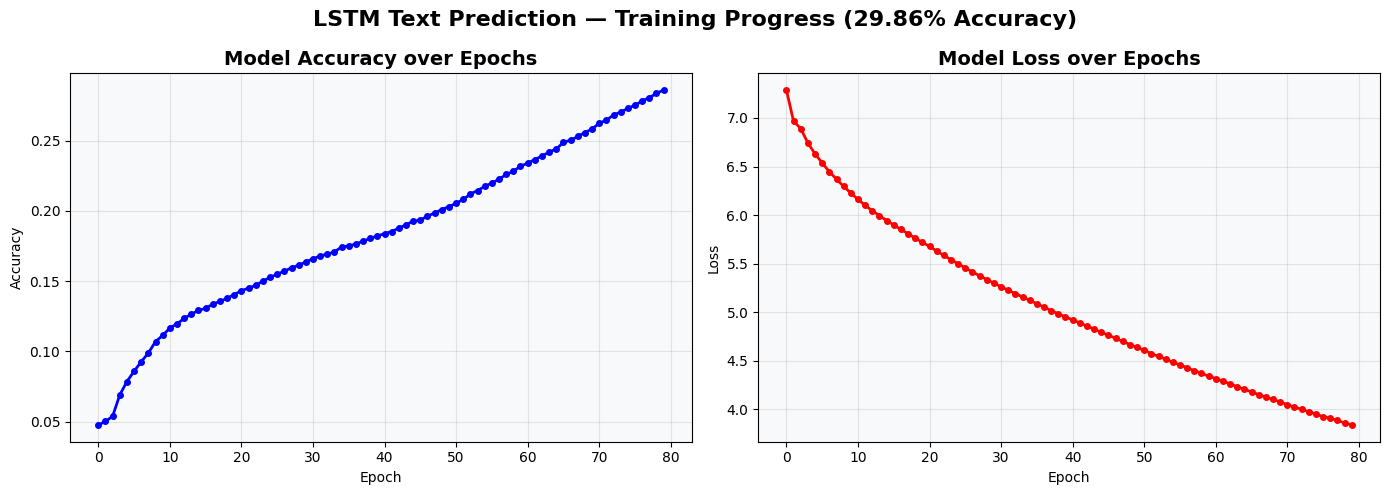

✅ Plot saved as training_progress.png


In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], color='blue', linewidth=2, marker='o', markersize=4)
ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# Plot Loss
ax2.plot(history.history['loss'], color='red', linewidth=2, marker='o', markersize=4)
ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8f9fa')

plt.suptitle('LSTM Text Prediction — Training Progress (29.86% Accuracy)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved as training_progress.png")

test

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_words(seed_text, num_words=5):
    result = seed_text
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break
        result += " " + predicted_word
    return result

# Test final model
print("🔮 Final model predictions:\n")

test_sentences = [
    "artificial intelligence is",
    "deep learning models are",
    "neural networks can learn",
    "machine learning is used",
    "computer science is the",
]

for sentence in test_sentences:
    prediction = predict_next_words(sentence, num_words=5)
    print(f"Input : '{sentence}'")
    print(f"Output: '{prediction}'")
    print()

🔮 Final model predictions:

Input : 'artificial intelligence is'
Output: 'artificial intelligence is the <OOV> of the field'

Input : 'deep learning models are'
Output: 'deep learning models are used to solve images from'

Input : 'neural networks can learn'
Output: 'neural networks can learn in the same time the'

Input : 'machine learning is used'
Output: 'machine learning is used to predict the term and'

Input : 'computer science is the'
Output: 'computer science is the <OOV> and kernel undermined dilemmas'



Restart FastAPI with New Model

In [14]:
import nest_asyncio
import uvicorn
import threading
import pickle
import numpy as np
from pyngrok import ngrok
from fastapi import FastAPI
from pydantic import BaseModel
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

nest_asyncio.apply()

# ---- Load saved model and tokenizer ----
loaded_model = load_model('lstm_text_model.h5')
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

SEQ_LENGTH = 10
VOCAB_SIZE = 8000

# ---- Define FastAPI app ----
app = FastAPI(
    title="LSTM Text Prediction API",
    description="Predicts next words in a sequence using LSTM model trained on Wikipedia data",
    version="2.0.0"
)

# ---- Request & Response models ----
class PredictRequest(BaseModel):
    seed_text: str
    num_words: int = 5

class PredictResponse(BaseModel):
    input_text: str
    predicted_text: str
    next_words: list

# ---- Endpoints ----
@app.get("/")
def home():
    return {
        "message": "LSTM Text Prediction API is running!",
        "version": "2.0.0",
        "accuracy": "29.86%",
        "endpoints": {
            "predict": "/predict",
            "docs": "/docs",
            "health": "/health"
        }
    }

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "LSTM",
        "vocab_size": VOCAB_SIZE,
        "accuracy": "29.86%"
    }

@app.post("/predict")
def predict(request: PredictRequest):
    result = request.seed_text
    next_words = []

    for _ in range(request.num_words):
        token_list = loaded_tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')
        predicted_probs = loaded_model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))

        predicted_word = ""
        for word, index in loaded_tokenizer.word_index.items():
            if index == predicted_index:
                predicted_word = word
                break

        next_words.append(predicted_word)
        result += " " + predicted_word

    return PredictResponse(
        input_text=request.seed_text,
        predicted_text=result,
        next_words=next_words
    )

# ---- Start ngrok + server ----
ngrok.set_auth_token("3CiH0ALxVWzRK3qH17KkKjQvHsv_2MZY5QGf8Jj58A88wf2bu")
public_url = ngrok.connect(8000)
print(f"✅ Public URL: {public_url}")
print(f"📖 Swagger Docs: {public_url}/docs")
print(f"🔮 Predict endpoint: {public_url}/predict")
print(f"\n⚠️  Keep this cell running!")

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

import time
while True:
    time.sleep(1)

INFO:     Started server process [16367]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ Public URL: NgrokTunnel: "https://chosen-commuting-privacy.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger Docs: NgrokTunnel: "https://chosen-commuting-privacy.ngrok-free.dev" -> "http://localhost:8000"/docs
🔮 Predict endpoint: NgrokTunnel: "https://chosen-commuting-privacy.ngrok-free.dev" -> "http://localhost:8000"/predict

⚠️  Keep this cell running!
INFO:     122.169.11.165:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     122.169.11.165:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     122.169.11.165:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     122.169.11.165:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     122.169.11.165:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     122.169.11.165:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     122.169.11.165:0 - "POST /predict HTTP/1.1" 200 OK


KeyboardInterrupt: 

In [16]:
from google.colab import files

# Download all important files
files.download('lstm_text_model.h5')
files.download('tokenizer.pkl')
files.download('prediction_api.py')
files.download('training_progress.png')

print("✅ All files downloading!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloading!
